# Argentina vs France – World Cup Final Analysis

This notebook analyzes the 2022 FIFA World Cup Final using event-level data.

The analysis focuses on:
- Lionel Messi's passing behavior
- Kylian Mbappé's attacking contributions
- Argentina's midfield defensive activity
- Team passing networks
- Cumulative expected goals (xG)

The goal is to provide both statistical insights and tactical interpretation of the match.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mplsoccer import Pitch, VerticalPitch, Sbopen
from statsbombpy import sb

import warnings
warnings.filterwarnings('ignore')

In [2]:
parser = Sbopen()

In [3]:
competitions = parser.competition()

# World Cup Filter 
wc = competitions[competitions['competition_name'] == 'FIFA World Cup']
wc

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
30,43,3,International,FIFA World Cup,male,False,True,2018,2024-06-12T07:38:19.345758,2021-06-13T16:17:31.694,None,2024-06-12T07:38:19.345758
31,43,55,International,FIFA World Cup,male,False,True,1990,2023-06-28T10:58:20.137929,2021-06-12T16:17:31.694,None,2023-06-28T10:58:20.137929
32,43,54,International,FIFA World Cup,male,False,True,1986,2023-12-26T22:34:04.263530,2021-06-13T16:17:31.694,None,2023-12-26T22:34:04.263530
33,43,51,International,FIFA World Cup,male,False,True,1974,2024-02-13T02:52:29.582599,2021-06-13T16:17:31.694,None,2024-02-13T02:52:29.582599
34,43,272,International,FIFA World Cup,male,False,True,1970,2024-02-13T14:23:06.735299,None,None,2024-02-13T14:23:06.735299
35,43,270,International,FIFA World Cup,male,False,True,1962,2023-06-26T10:38:00.323984,None,None,2023-06-26T10:38:00.323984
36,43,269,International,FIFA World Cup,male,False,True,1958,2024-02-13T14:22:08.222297,None,None,2024-02-13T14:22:08.222297


In [4]:
# 2022 World Cup IDs
competition_id = 43
season_id = 106

In [5]:
matches = parser.match(competition_id=competition_id, season_id=season_id)

matches.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,3857256,2022-12-02,2022-12-02 21:00:00,2,3,available,available,2023-02-17 23:45:15.306706,2023-04-26 23:49:58.956186,3,...,10,Group Stage,1001115,Stadium 974,185,Qatar,1121.0,Fernando Andrés Rapallini,11.0,Argentina
1,3869151,2022-12-03,2022-12-03 21:00:00,2,1,available,available,2023-07-30 07:46:05.382784,2023-07-30 07:48:51.865595,4,...,33,Round of 16,1000793,Ahmad bin Ali Stadium,185,Qatar,367.0,Szymon Marciniak,182.0,Poland
2,3857257,2022-11-30,2022-11-30 17:00:00,1,0,available,available,2023-04-28 17:13:10.958725,2023-06-20 11:04:37.638969,3,...,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,2311.0,Mustapha Ghorbal,4.0,Algeria
3,3857258,2022-11-24,2022-11-24 21:00:00,2,0,available,available,2023-06-24 17:17:27.911026,2023-07-11 14:56:31.096588,1,...,10,Group Stage,1001114,Lusail Stadium,185,Qatar,741.0,Alireza Faghani,107.0,"Iran, Islamic Republic of"
4,3857288,2022-11-26,2022-11-26 12:00:00,0,1,available,available,2023-02-28 21:25:20.888552,2023-04-27 00:30:07.835815,2,...,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,225.0,Daniel Siebert,85.0,Germany


In [6]:
# Argentina vs France final
final_match = matches[
    ((matches['home_team_name'] == 'Argentina') & (matches['away_team_name'] == 'France')) |
    ((matches['home_team_name'] == 'France') & (matches['away_team_name'] == 'Argentina'))
]

final_match[['match_id', 'match_date', 'home_team_name', 'away_team_name']]

,match_id,match_date,home_team_name,away_team_name
9,3869685,2022-12-18,Argentina,France


In [7]:
match_id = final_match.iloc[0]['match_id']

In [8]:
df, related, freeze, tactics = parser.event(match_id)

df.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_committed_card_id,foul_committed_card_name,ball_recovery_offensive,shot_one_on_one,foul_committed_advantage,foul_won_advantage,block_offensive,foul_committed_offensive,bad_behaviour_card_id,bad_behaviour_card_name
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,1,1,00:00:00,0,0,1,0.000000,3869685,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,2,1,00:00:00,0,0,1,0.000000,3869685,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3,1,00:00:00,0,0,1,0.000000,3869685,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6404a8e8-afaf-489d-b65e-173a237ffed5,4,1,00:00:00,0,0,1,0.000000,3869685,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,00:00:00,0,0,2,0.975702,3869685,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df['type_name'].value_counts()

type_name
Pass               1263
Ball Receipt       1114
Carry               940
Pressure            361
Ball Recovery       115
Duel                 98
Dribble              54
Block                50
Foul Committed       48
Clearance            45
Foul Won             44
Goal Keeper          44
Shot                 38
Miscontrol           35
Dispossessed         34
Dribbled Past        31
Interception         28
Substitution         13
Half Start           10
Half End             10
Injury Stoppage       9
50/50                 8
Tactical Shift        7
Starting XI           2
Bad Behaviour         2
Offside               1
Shield                1
Player On             1
Player Off            1
Name: count, dtype: int64

In [10]:
df['team_name'].value_counts()

team_name
Argentina    2372
France       2035
Name: count, dtype: int64

In [11]:
df['player_name'].value_counts()

player_name
Enzo Fernandez                     328
Lionel Andrés Messi Cuccittini     242
Rodrigo Javier De Paul             242
Nicolás Hernán Otamendi            215
Jules Koundé                       211
Aurélien Djani Tchouaméni          205
Cristian Gabriel Romero            203
Dayotchanculle Upamecano           198
Alexis Mac Allister                196
Raphaël Varane                     182
Adrien Rabiot                      176
Nicolás Alejandro Tagliafico       165
Julián Álvarez                     150
Kylian Mbappé Lottin               149
Theo Bernard François Hernández    145
Nahuel Molina Lucero               142
Ángel Fabián Di María Hernández    132
Randal Kolo Muani                  127
Marcus Thuram                      119
Marcos Javier Acuña                112
Antoine Griezmann                  103
Hugo Lloris                         97
Kingsley Coman                      85
Damián Emiliano Martínez            83
Eduardo Camavinga                   83
Gonzalo Ariel

In [12]:
shots = df[df['type_name'] == 'Shot'].copy()
passes = df[df['type_name'] == 'Pass'].copy()
carries = df[df['type_name'] == 'Carry'].copy()
pressures = df[df['type_name'] == 'Pressure'].copy()

In [13]:
messi_name = 'Lionel Andrés Messi Cuccittini'

messi_passes = df[
    (df['type_name'] == 'Pass') &
    (df['player_name'] == messi_name)
].copy()

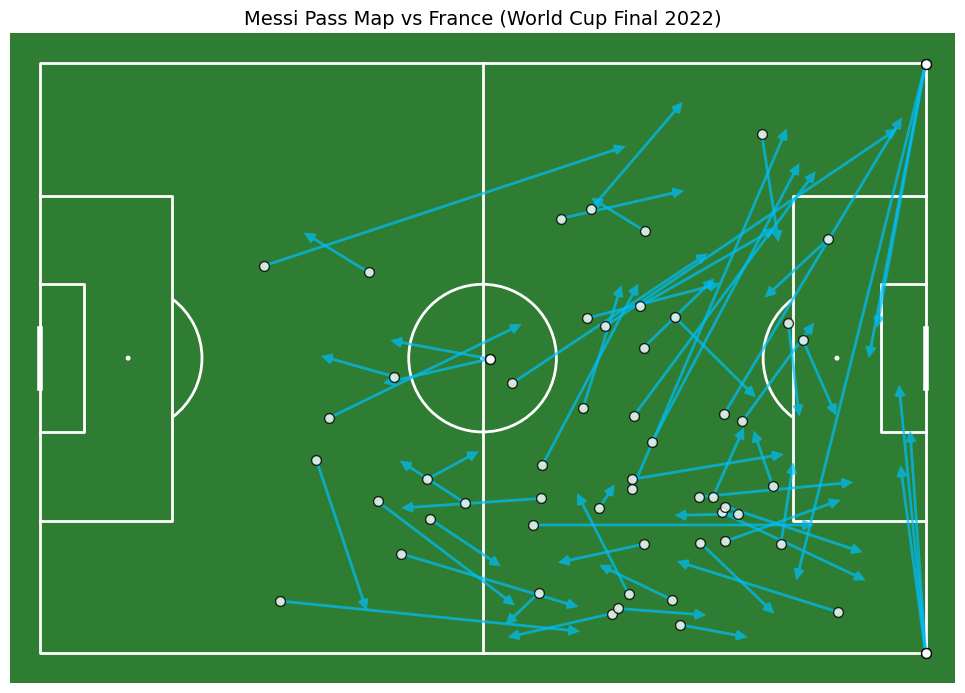

In [14]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#2e7d32',
    line_color='white'
)

fig, ax = pitch.draw(figsize=(10, 7))

# Arrows showing direction and length of Messi's passes
pitch.arrows(
    messi_passes.x, messi_passes.y,
    messi_passes.end_x, messi_passes.end_y,
    color='#00BFFF',
    ax=ax,
    width=2,
    headwidth=4,
    headlength=4,
    alpha=0.7
)

# Pass starting points
pitch.scatter(
    messi_passes.x,
    messi_passes.y,
    color='white',
    edgecolors='black',
    s=50,
    alpha=0.8,
    ax=ax
)

plt.title("Messi Pass Map vs France (World Cup Final 2022)", fontsize=14)
plt.show()

## 1. Messi Pass Map

###  Key Observations
- Messi frequently drops into deeper zones to receive the ball.
- Most of his passes are vertical and progressive.
- Passing activity is slightly biased towards the left side.

###  Tactical Interpretation
Messi operates as a hybrid between a No.10 and a deep-lying playmaker, supporting build-up while progressing the ball forward. 
Argentina primarily constructed their attacks on the left flank, utilizing the creativity of Mac Allister and Di Maria 
to create overloads and exploit France’s defensive structure.

###  Match Impact
This role enabled Argentina to control tempo and consistently break France’s defensive lines, 
especially during the first half.

###  Insight
Messi functioned as the main progression hub rather than a final-third finisher.

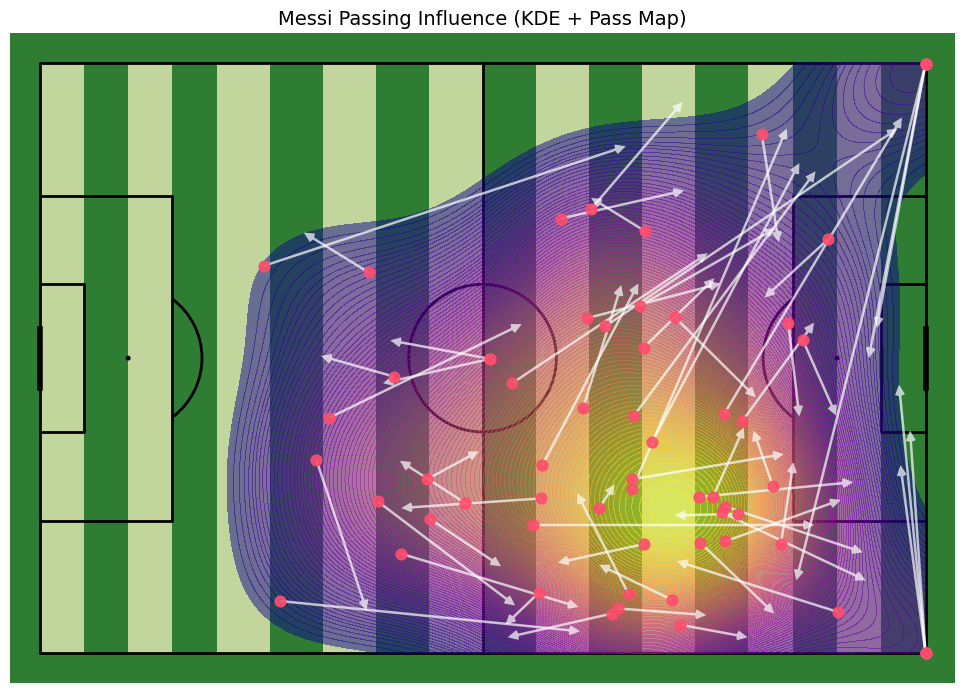

In [15]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#2e7d32',
    line_color='black',
    stripe=True
)

fig, ax = pitch.draw(figsize=(10, 7))

# Density map of Messi's pass origins to highlight his main playmaking zones
pitch.kdeplot(
    messi_passes.x,
    messi_passes.y,
    ax=ax,
    fill=True,
    levels=100,
    cmap='plasma',
    alpha=0.5
)

# Arrows showing direction and length of Messi's passes
pitch.arrows(
    messi_passes.x,
    messi_passes.y,
    messi_passes.end_x,
    messi_passes.end_y,
    color='white',
    ax=ax,
    width=1.8,
    headwidth=4,
    headlength=4,
    alpha=0.7
)

# Pass starting points
pitch.scatter(
    messi_passes.x,
    messi_passes.y,
    color='#ff4d6d', 
    s=60,
    alpha=0.9,
    ax=ax
)

plt.title("Messi Passing Influence (KDE + Pass Map)", fontsize=14)
plt.show()

## 2. Messi Pass Heatmap (KDE)

###  Key Observations
- Messi’s activity is concentrated in the right half-space and central attacking midfield zones.
- He maintains a strong presence between the lines, with limited involvement in deeper areas.

###  Tactical Interpretation
Messi operates as a central reference point between France’s midfield and defensive lines, positioning himself to receive in dangerous pockets. 
Supported by ball-winning midfielders like Enzo Fernández and Rodrigo De Paul, he is able to stay higher rather than dropping deep.

This advanced positioning also limits Theo Hernández’s attacking freedom, as Messi occupies his zone and prevents him from fully committing forward.

###  Match Impact
Argentina consistently accessed central areas and controlled attacking sequences, 
while also restricting France’s left-side attacking contribution.

###  Insight
Messi’s influence is driven by intelligent positioning rather than constant involvement.

In [16]:
mbappe_name = 'Kylian Mbappé Lottin'

mbappe_shots = df[
    (df['type_name'] == 'Shot') &
    (df['player_name'] == mbappe_name)
].copy()

mbappe_carries = df[
    (df['type_name'] == 'Carry') &
    (df['player_name'] == mbappe_name)
].copy()

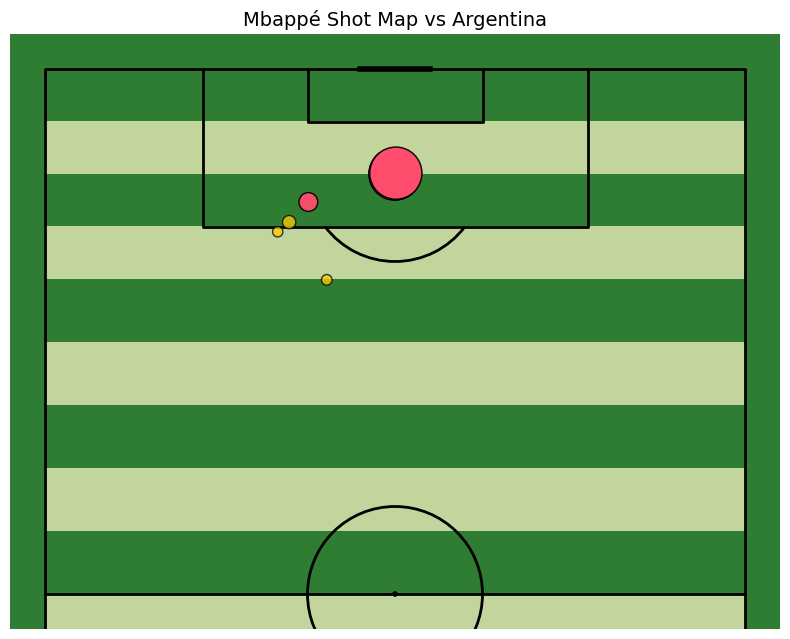

In [17]:
pitch = VerticalPitch(
    pitch_type='statsbomb',
    pitch_color='#2e7d32',
    line_color='black',
    stripe=True,
    half=True
)

fig, ax = pitch.draw(figsize=(8, 10))

# Splitting Mbappé's shots into goals vs non-goals based on outcome
mbappe_goals = mbappe_shots[mbappe_shots['outcome_name'] == 'Goal']
mbappe_non_goals = mbappe_shots[mbappe_shots['outcome_name'] != 'Goal']

# Non-goal shots
pitch.scatter(
    mbappe_non_goals.x,
    mbappe_non_goals.y,
    # Marker size proportional to xG
    s=mbappe_non_goals['shot_statsbomb_xg'] * 1800,
    color='#ffcc00',
    edgecolors='black',
    alpha=0.75,
    ax=ax
)

# Goals
pitch.scatter(
    mbappe_goals.x,
    mbappe_goals.y,
    s=mbappe_goals['shot_statsbomb_xg'] * 1800, 
    color='#ff4d6d',
    edgecolors='black',
    alpha=0.95,
    ax=ax
)

plt.title("Mbappé Shot Map vs Argentina", fontsize=14)
plt.show()

## 3. Mbappé Shot Map

###  Key Observations
- Mbappé’s shot volume is relatively low, with only a few attempts throughout the match.
- Two of his goals come from penalties, while one is from open play.
- Most shots are taken from central areas inside or around the penalty box.

###  Tactical Interpretation
Mbappé was largely isolated for significant portions of the match, especially during the first 60 minutes, 
as France struggled to progress the ball into attacking zones.

However, his positioning remained central and advanced, allowing him to capitalize on high-value moments when they emerged. 
Rather than being consistently involved, he relied on explosive actions and key situations.

###  Match Impact
Despite limited involvement, Mbappé scored a hat-trick, demonstrating exceptional efficiency and composure under pressure. 
His goals completely shifted the momentum of the match and brought France back into the game.

###  Insight
Mbappé’s performance highlights how elite attackers can decide games with minimal touches, 
turning low involvement into maximum impact.

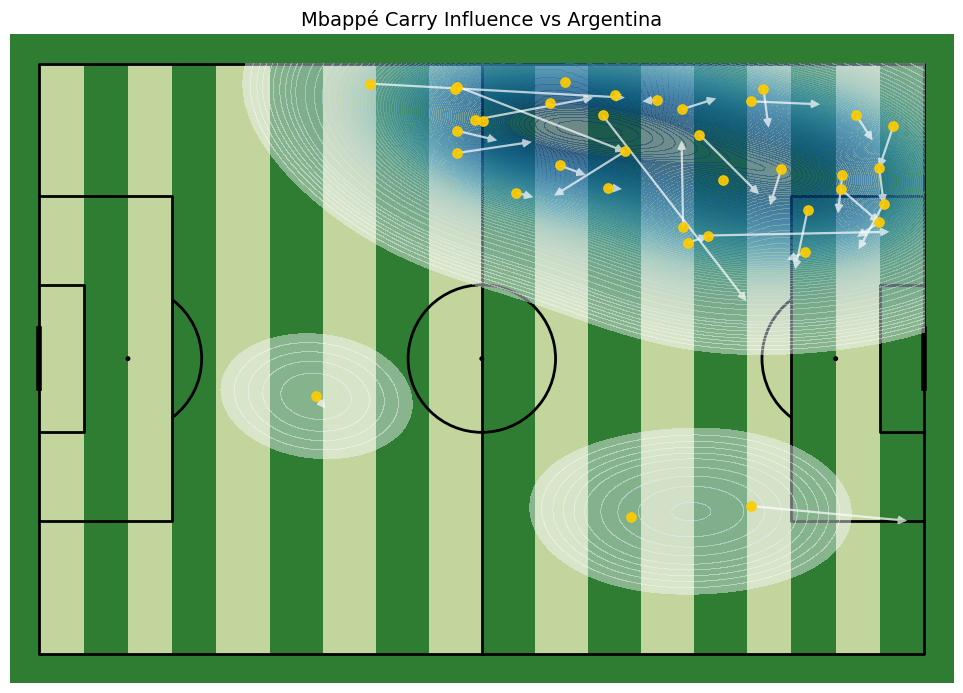

In [18]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#2e7d32',
    line_color='black',
    stripe=True
)

fig, ax = pitch.draw(figsize=(10, 7))

# KDE heatmap to show spatial density of Mbappé's carries
pitch.kdeplot(
    mbappe_carries.x,
    mbappe_carries.y,
    ax=ax,
    fill=True,
    levels=100,
    cmap='Blues',
    alpha=0.45
)

# Arrows representing direction and progression of each carry
pitch.arrows(
    mbappe_carries.x,
    mbappe_carries.y,
    mbappe_carries.end_x,
    mbappe_carries.end_y,
    color='white',
    ax=ax,
    width=1.6,
    headwidth=4,
    headlength=4,
    alpha=0.7
)

pitch.scatter(
    mbappe_carries.x,
    mbappe_carries.y,
    color='#ffcc00',
    s=45,
    alpha=0.9,
    ax=ax
)

plt.title("Mbappé Carry Influence vs Argentina", fontsize=14)
plt.show()

## 4. Mbappé Carry Map

###  Key Observations
- Mbappé’s carries are heavily concentrated on the left side and inside channels.
- Most of his ball progressions move directly towards the penalty area.
- Limited involvement in deeper build-up zones.

###  Tactical Interpretation
Mbappé primarily operates in transition phases, receiving the ball in advanced areas and driving forward with pace. 
His carries are direct and aggressive, targeting central spaces rather than wide isolation.

The left-sided concentration suggests he exploits space behind Argentina’s right side, 
especially during moments when defensive structure is temporarily broken.

###  Match Impact
Mbappé’s ball-carrying ability allowed France to quickly turn defensive situations into attacking threats, 
playing a key role in their comeback phase.

In [19]:
argentina_midfielders = [
    'Rodrigo Javier De Paul',
    'Enzo Fernandez',
    'Alexis Mac Allister'
]

In [20]:
# Keep only defensive events from Argentina's midfielders
def_actions = df[
    (df['player_name'].isin(argentina_midfielders)) &
    (df['type_name'].isin([
        'Pressure',
        'Interception',
        'Ball Recovery',
        'Duel',
        'Block'
    ]))
].copy()

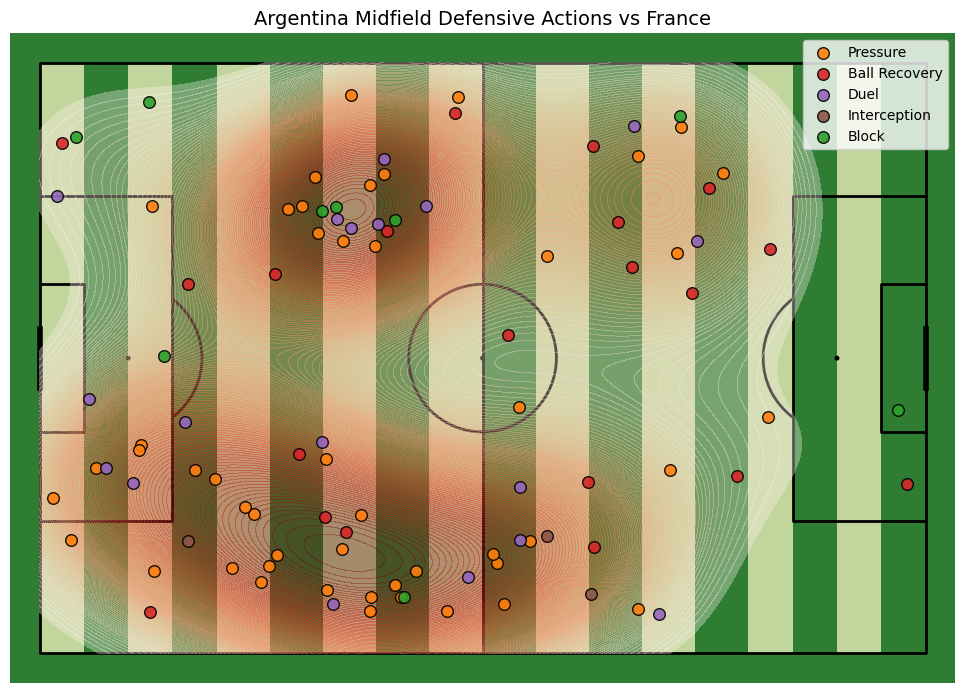

In [21]:
colors = {
    'Pressure': '#ff7f0e',        
    'Ball Recovery': '#d62728',   
    'Duel': '#9467bd',            
    'Interception': '#8c564b',    
    'Block': '#2ca02c'            
}

pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#2e7d32',
    line_color='black',
    stripe=True
)

fig, ax = pitch.draw(figsize=(10, 7))

# KDE heatmap showing the overall spatial density of midfield defensive actions
pitch.kdeplot(
    def_actions.x,
    def_actions.y,
    ax=ax,
    fill=True,
    levels=100,
    cmap='Reds',
    alpha=0.35
)

# Overlaying each defensive action type as a separate scatter layer
for action, color in colors.items():
    subset = def_actions[def_actions['type_name'] == action]
    
    pitch.scatter(
        subset.x,
        subset.y,
        color=color,
        s=70,
        edgecolors='black',
        alpha=0.9,
        ax=ax,
        label=action
    )

ax.legend(loc='upper right')

plt.title("Argentina Midfield Defensive Actions vs France", fontsize=14)
plt.show()

## 5. Argentina Midfield Defensive Actions Map

###  Key Observations
- Defensive actions are concentrated on both flanks, limiting wide progression.
- France’s right side shows significantly reduced activity.
- Strong central presence with frequent pressures and ball recoveries.

###  Tactical Interpretation
Argentina’s midfield effectively controlled wide areas, preventing France from building attacks through the flanks. 
France’s right side, in particular, remained largely inactive, which is also linked to Dembélé’s early substitution (41’), 
disrupting their attacking balance.

###  Match Impact
France struggled to generate width and attacking variety, 
making their offensive play more predictable and easier to contain.

###  Insight
Argentina dictated where France could not play, rather than just reacting defensively.

In [22]:
# Argentina passes (exclude throw-ins)
arg_passes = df[
    (df['type_name'] == 'Pass') &
    (df['team_name'] == 'Argentina') &
    (df['sub_type_name'] != 'Throw-in')
].copy()

arg_players = arg_passes['player_name'].dropna().unique()

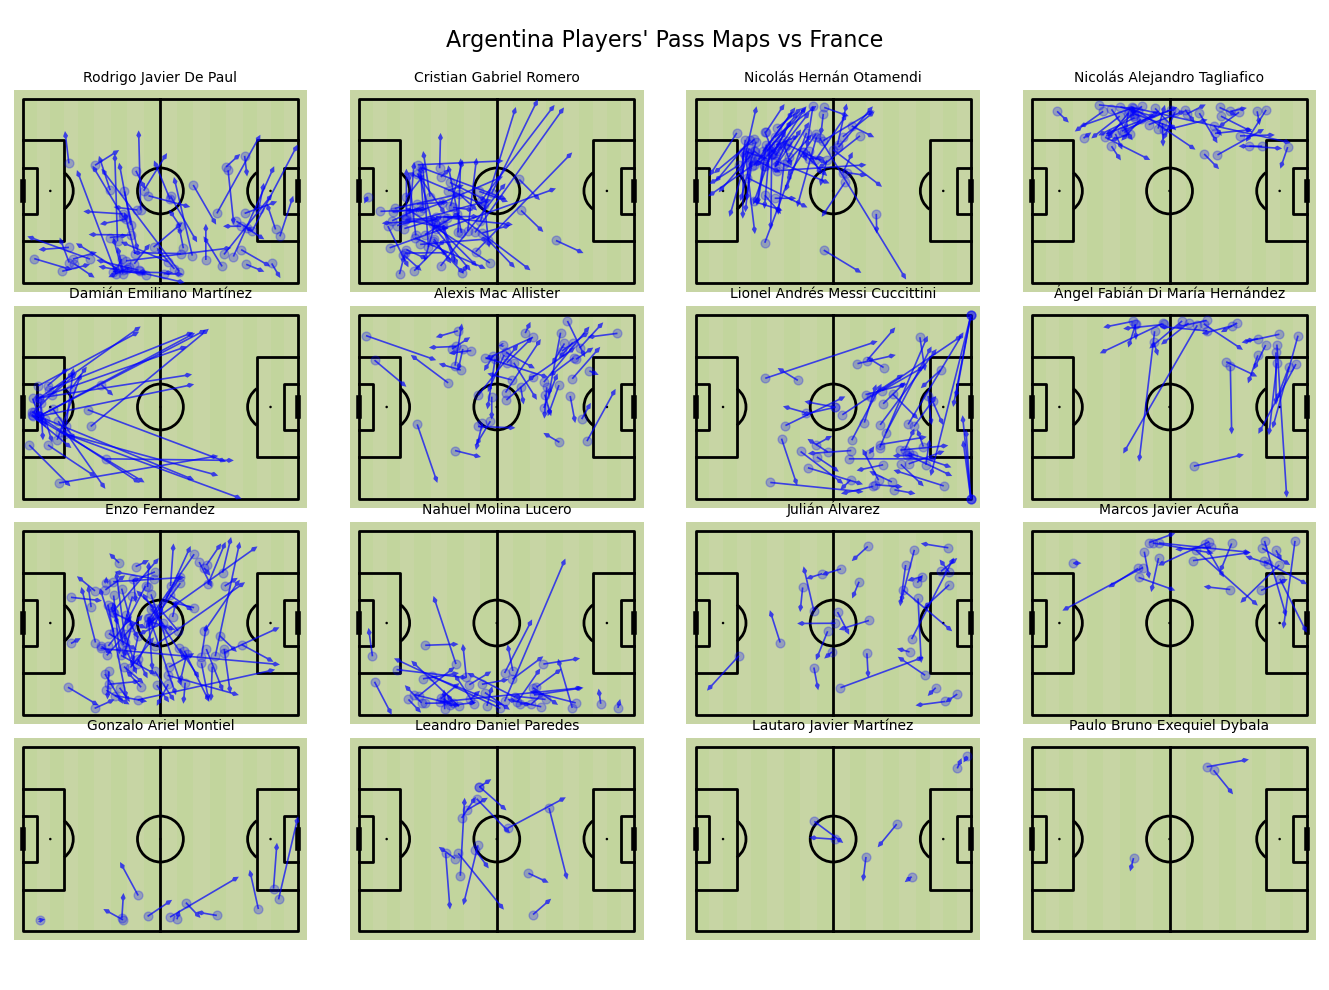

In [23]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#c7d5a4',
    stripe=True,
    line_color='black'
)

fig, axs = pitch.grid(
    ncols=4,
    nrows=4,
    grid_height=0.85,
    title_height=0.06,
    axis=False,
    endnote_height=0.03,
    title_space=0.02,
    endnote_space=0.01
)

fig.set_size_inches(14, 10)

# Create one pass map per player to compare individual passing profiles 
for name, ax in zip(arg_players, axs['pitch'].flat[:len(arg_players)]):
    player_df = arg_passes[arg_passes['player_name'] == name]

    pitch.scatter(
        player_df.x,
        player_df.y,
        alpha=0.25,
        s=40,
        color='blue',
        ax=ax
    )
    # Plot pass directions and lengths for the current player
    pitch.arrows(
        player_df.x,
        player_df.y,
        player_df.end_x,
        player_df.end_y,
        color='blue',
        ax=ax,
        width=1.2,
        headwidth=3,
        headlength=3,
        alpha=0.7
    )

    ax.set_title(name, fontsize=10, pad=6)

# Remove unused subplot axes 
for ax in axs['pitch'].flat[len(arg_players):]:
    ax.remove()

axs['title'].text(
    0.5, 0.5,
    "Argentina Players' Pass Maps vs France",
    ha='center', va='center',
    fontsize=16
)

plt.show()

## 6. Argentina Players' Pass Maps

###  Key Observations
- Defenders (Romero, Otamendi) are heavily involved in build-up with frequent forward passes.
- Midfielders, especially Enzo Fernández and Mac Allister, operate centrally with high passing density.
- Fullbacks (Tagliafico, Molina) are active in wide areas, supporting progression.
- Messi shows a free role, connecting midfield and attack.

###  Tactical Interpretation
Argentina builds through a structured system starting from the back, with center-backs initiating play and midfielders controlling central zones. 
Enzo Fernández acts as the main distribution hub, while Mac Allister supports progression between lines.

Wide players and fullbacks provide width, while Messi operates freely to link play and create overloads, 
resulting in a balanced and well-connected attacking structure.

###  Match Impact
This structure allowed Argentina to maintain control of possession and progress the ball efficiently, 
making it difficult for France to disrupt their build-up.

###  Insight
Argentina’s strength lies in collective structure rather than individual dependency.

In [24]:
fra_passes = df[
    (df['type_name'] == 'Pass') &
    (df['team_name'] == 'France') &
    (df['sub_type_name'] != 'Throw-in')
].copy()

fra_players = fra_passes['player_name'].dropna().unique()

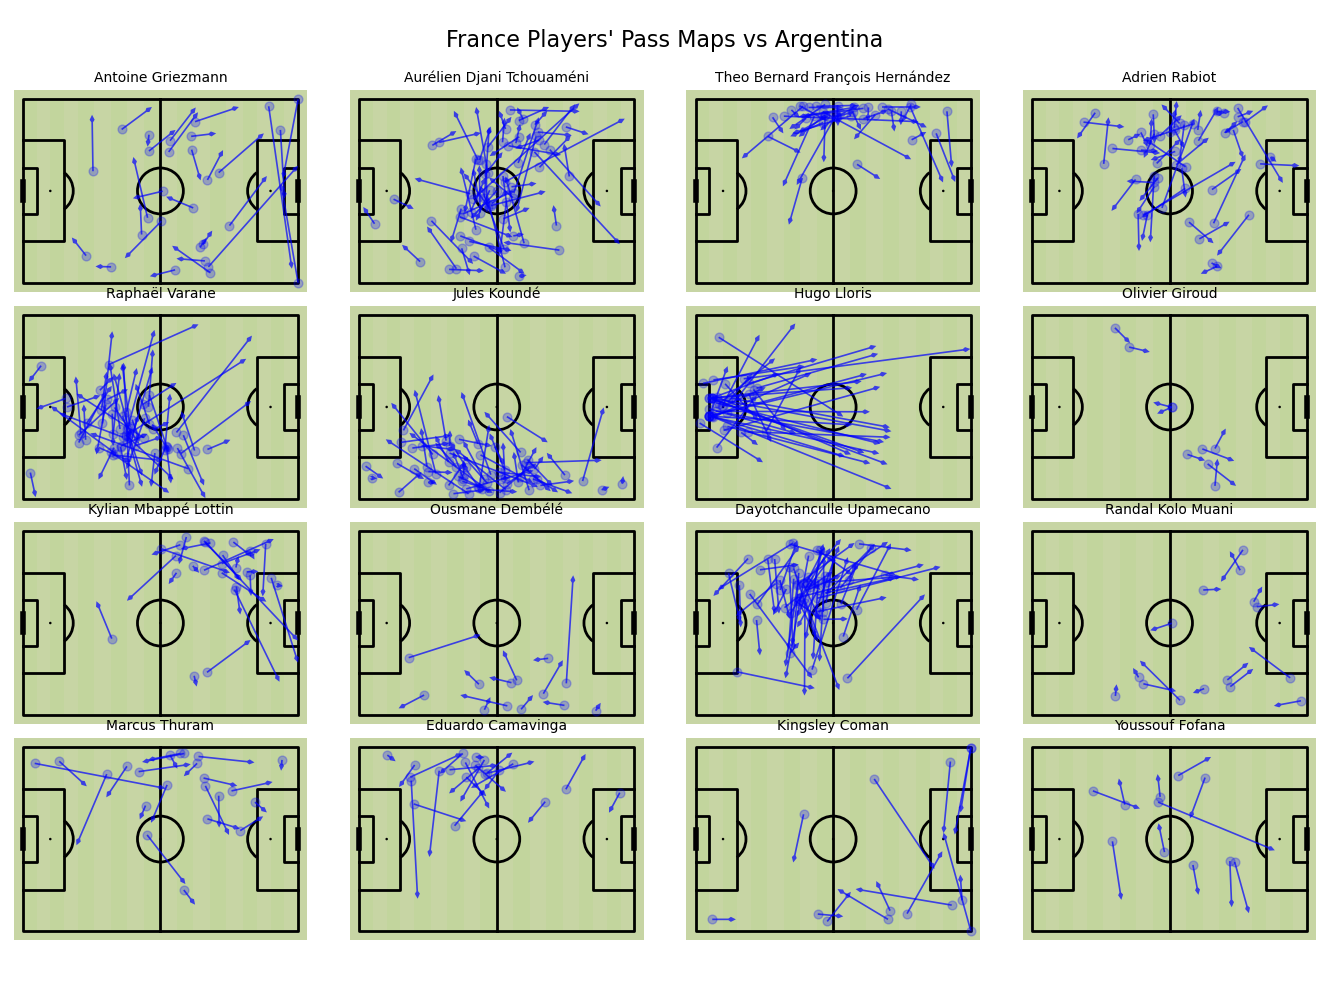

In [25]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#c7d5a4',
    stripe=True,
    line_color='black'
)

fig, axs = pitch.grid(
    ncols=4,
    nrows=4,
    grid_height=0.85,
    title_height=0.06,
    axis=False,
    endnote_height=0.03,
    title_space=0.02,
    endnote_space=0.01
)

fig.set_size_inches(14, 10)

# Create one pass map per player to compare individual passing profiles 
for name, ax in zip(fra_players, axs['pitch'].flat[:len(fra_players)]):
    player_df = fra_passes[fra_passes['player_name'] == name]

    pitch.scatter(
        player_df.x,
        player_df.y,
        alpha=0.25,
        s=40,
        color='blue',
        ax=ax
    )
    
    # Plot pass directions and lengths for the current player
    pitch.arrows(
        player_df.x,
        player_df.y,
        player_df.end_x,
        player_df.end_y,
        color='blue',
        ax=ax,
        width=1.2,
        headwidth=3,
        headlength=3,
        alpha=0.7
    )

    ax.set_title(name, fontsize=10, pad=6)

# Remove unused subplot axes 
for ax in axs['pitch'].flat[len(fra_players):]:
    ax.remove()

axs['title'].text(
    0.5, 0.5,
    "France Players' Pass Maps vs Argentina",
    ha='center', va='center',
    fontsize=16
)

plt.show()

## 7. France Players' Pass Maps

###  Key Observations
- Passing activity is fragmented, with limited connections between lines.
- Midfielders show high activity but lack clear progressive structure.
- Wide players (Mbappé, Dembélé) operate in isolation.
- Build-up often relies on long passes from the goalkeeper and defenders.

###  Tactical Interpretation
France lacks a cohesive build-up structure, with players operating in disconnected zones rather than a coordinated system. 
The midfield fails to effectively link defense and attack, forcing the team to rely on individual actions and direct play.

Wide players are often isolated, receiving the ball without sufficient support, which limits their effectiveness despite their individual quality.

###  Match Impact
This structural disconnection made it difficult for France to sustain possession or build consistent attacking sequences, 
especially during the first half.

###  Insight
France played through individuals, while Argentina played through structure.

In [26]:
# Argentina all events for positioning heatmaps
arg_events = df[
    (df['team_name'] == 'Argentina') &
    (df['x'].notna()) &
    (df['y'].notna()) &
    (df['player_name'].notna())
].copy()

arg_players = arg_events['player_name'].unique()

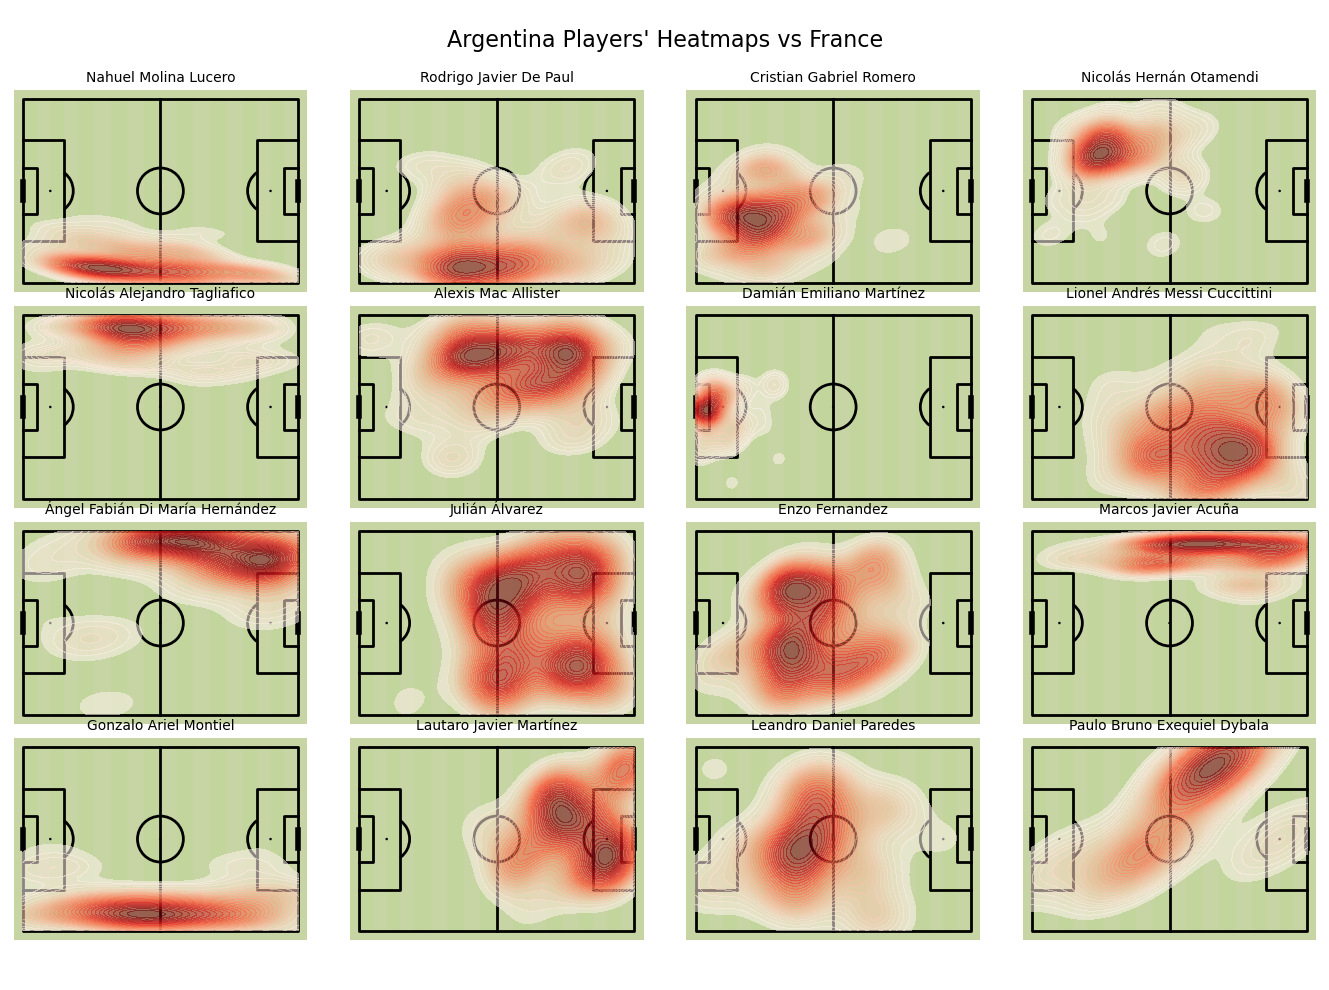

In [27]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#c7d5a4',
    stripe=True,
    line_color='black'
)

fig, axs = pitch.grid(
    ncols=4,
    nrows=4,
    grid_height=0.85,
    title_height=0.06,
    axis=False,
    endnote_height=0.03,
    title_space=0.02,
    endnote_space=0.01
)

fig.set_size_inches(14, 10)

# Create one positional heatmap per Argentina player
for name, ax in zip(arg_players, axs['pitch'].flat[:len(arg_players)]):
    player_df = arg_events[arg_events['player_name'] == name]

    # Plot positional heatmap for the current player
    pitch.kdeplot(
        player_df.x,
        player_df.y,
        ax=ax,
        fill=True,
        levels=30,
        cmap='Reds',
        alpha=0.55
    )

    ax.set_title(name, fontsize=10, pad=6)

# Remove unused subplot axes
for ax in axs['pitch'].flat[len(arg_players):]:
    ax.remove()

axs['title'].text(
    0.5, 0.5,
    "Argentina Players' Heatmaps vs France",
    ha='center', va='center',
    fontsize=16
)

plt.show()

## 8. Argentina Players' Heatmaps

###  Key Observations
- Álvarez shows high defensive involvement, frequently dropping deep across multiple zones.
- De Paul is highly active on the right side, covering large areas.
- Acuña has strong presence in advanced wide areas despite being a substitute.
- Overall team structure shows balanced occupation of both central and wide zones.

###  Tactical Interpretation
Álvarez operates as a highly mobile forward, contributing defensively and supporting midfield rather than staying fixed in attacking positions. 
De Paul’s intense activity on the right flank reflects a deliberate effort to contain Mbappé, using physicality and work rate to limit his influence.

Acuña’s advanced positioning after coming on indicates Argentina’s intent to maintain attacking width and energy in later stages of the match.

###  Match Impact
Argentina’s collective work rate and positional discipline allowed them to control both defensive transitions and wide areas, 
limiting France’s attacking effectiveness.

In [28]:
# France all events for positioning heatmaps
fra_events = df[
    (df['team_name'] == 'France') &
    (df['x'].notna()) &
    (df['y'].notna()) &
    (df['player_name'].notna())
].copy()

fra_players = fra_events['player_name'].unique()

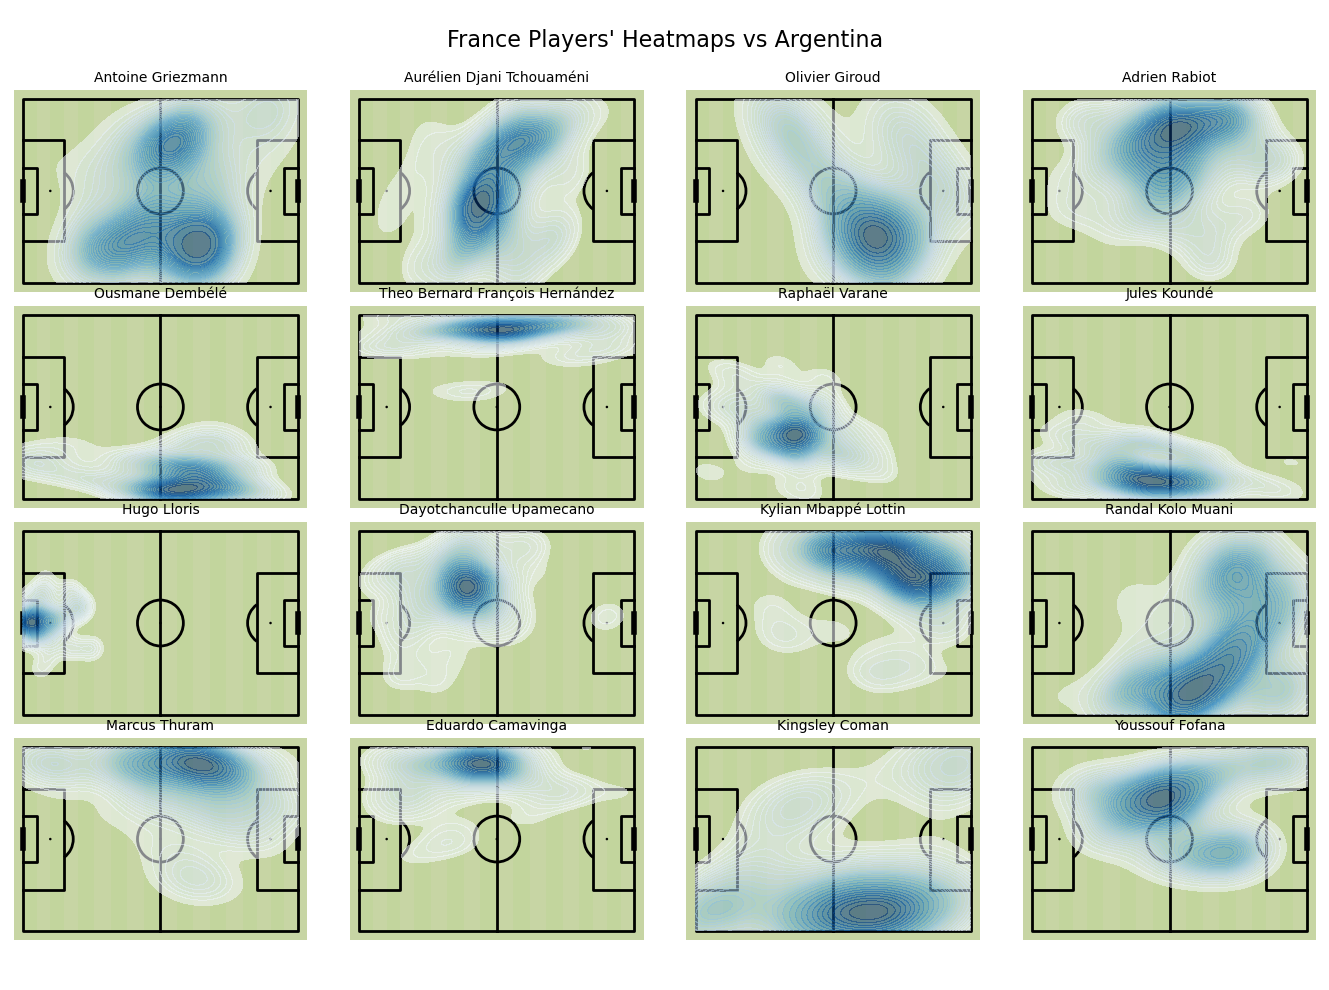

In [29]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#c7d5a4',
    stripe=True,
    line_color='black'
)

fig, axs = pitch.grid(
    ncols=4,
    nrows=4,
    grid_height=0.85,
    title_height=0.06,
    axis=False,
    endnote_height=0.03,
    title_space=0.02,
    endnote_space=0.01
)

fig.set_size_inches(14, 10)

# Create one positional heatmap per France player
for name, ax in zip(fra_players, axs['pitch'].flat[:len(fra_players)]):
    player_df = fra_events[fra_events['player_name'] == name]

    # Plot positional heatmap for the current player
    pitch.kdeplot(
        player_df.x,
        player_df.y,
        ax=ax,
        fill=True,
        levels=30,
        cmap='Blues',
        alpha=0.55
    )

    ax.set_title(name, fontsize=10, pad=6)

# Remove unused subplot axes
for ax in axs['pitch'].flat[len(fra_players):]:
    ax.remove()

axs['title'].text(
    0.5, 0.5,
    "France Players' Heatmaps vs Argentina",
    ha='center', va='center',
    fontsize=16
)

plt.show()

## 9. France Players' Heatmaps

###  Key Observations
- Attacking players like Giroud and Thuram show deeper and less concentrated heatmaps than expected.
- Overall player activity appears more dispersed and less intense compared to Argentina.
- Limited presence in advanced central zones.

###  Tactical Interpretation
France’s attacking players, particularly Giroud and Thuram, are forced into deeper positions, 
indicating a lack of sustained attacking presence in the final third.

Compared to Argentina, France’s heatmaps appear less intense and more scattered, 
reflecting a team that struggles to occupy dangerous spaces collectively.

###  Match Impact
This lack of advanced positioning and spatial control limits France’s ability to create structured attacks, 
forcing them to rely on individual moments rather than consistent pressure.

###  Insight
France’s “colder” heatmap reflects not just lower activity, but weaker spatial dominance.

In [30]:
# Argentina completed passes only (exclude throw-ins)
arg_passes = df[
    (df['team_name'] == 'Argentina') &
    (df['type_name'] == 'Pass') &
    (df['sub_type_name'] != 'Throw-in') &
    (df['outcome_name'].isna())
].copy()

In [31]:
# Average location + pass count per player
arg_nodes = (
    arg_passes.groupby('player_name')
    .agg(
        avg_x=('x', 'mean'),
        avg_y=('y', 'mean'),
        pass_count=('id', 'count')
    )
    .reset_index()
)

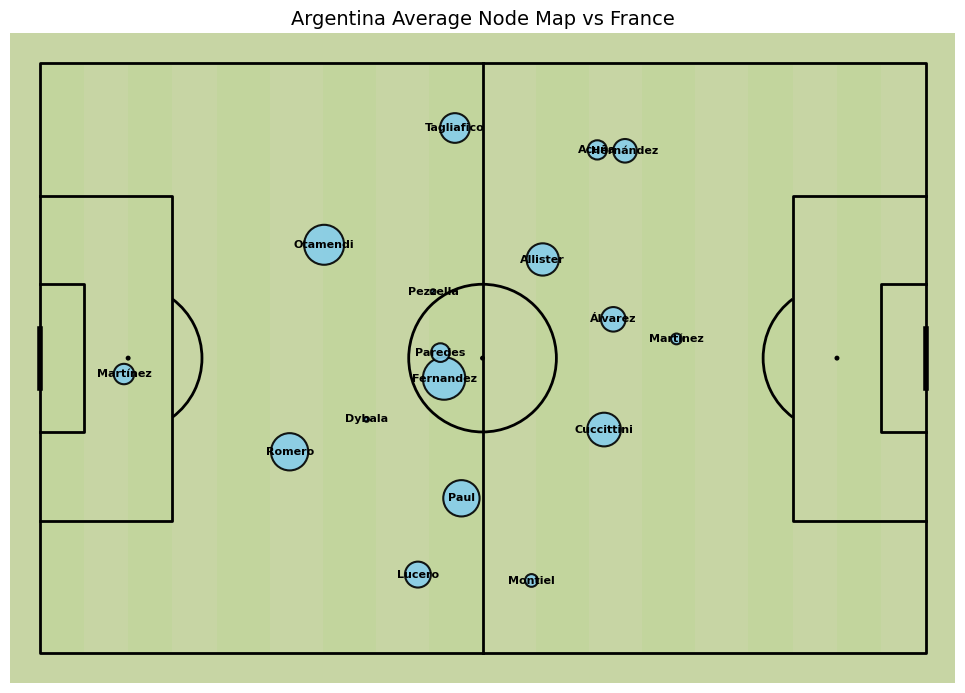

In [32]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#c7d5a4',
    stripe=True,
    line_color='black'
)

fig, ax = pitch.draw(figsize=(10, 7))

# Plot each player's average passing location
pitch.scatter(
    arg_nodes['avg_x'],
    arg_nodes['avg_y'],
    # Node size reflects pass volume
    s=arg_nodes['pass_count'] * 12,
    color='skyblue',
    edgecolors='black',
    linewidth=1.5,
    alpha=0.9,
    ax=ax
)

# Label nodes with player surnames 
for _, row in arg_nodes.iterrows():
    ax.text(
        row['avg_x'],
        row['avg_y'],
        row['player_name'].split()[-1], 
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color='black'
    )

plt.title("Argentina Average Node Map vs France", fontsize=14)
plt.show()

## 10. Argentina Average Node Map

###  Key Observations
- Álvarez drops deeper and drifts wide, creating space in central attacking areas.
- De Paul positions himself closer to Mbappé’s side.
- Montiel holds a relatively advanced position on the right flank.
- Enzo Fernández occupies a central role, anchoring midfield structure.

###  Tactical Interpretation
Álvarez’s movement away from the central striker position creates space for others by dragging defenders and opening passing lanes. 
De Paul’s positioning towards Mbappé’s side reflects a clear defensive assignment, providing support against France’s main threat.

This allows Montiel to push higher on the right flank, contributing more actively to attacking phases. 
Meanwhile, Enzo Fernández acts as the central stabilizer, maintaining balance and controlling the midfield.

###  Match Impact
Argentina achieves both defensive security and attacking width, 
allowing them to control transitions while maintaining offensive presence.

###  Insight
Argentina’s structure is built on coordinated role distribution, not fixed positions.

In [33]:
# France completed passes only (exclude throw-ins)
fra_passes = df[
    (df['team_name'] == 'France') &
    (df['type_name'] == 'Pass') &
    (df['sub_type_name'] != 'Throw-in') &
    (df['outcome_name'].isna())
].copy()

In [34]:
# Average location + pass count per player
fra_nodes = (
    fra_passes.groupby('player_name')
    .agg(
        avg_x=('x', 'mean'),
        avg_y=('y', 'mean'),
        pass_count=('id', 'count')
    )
    .reset_index()
)

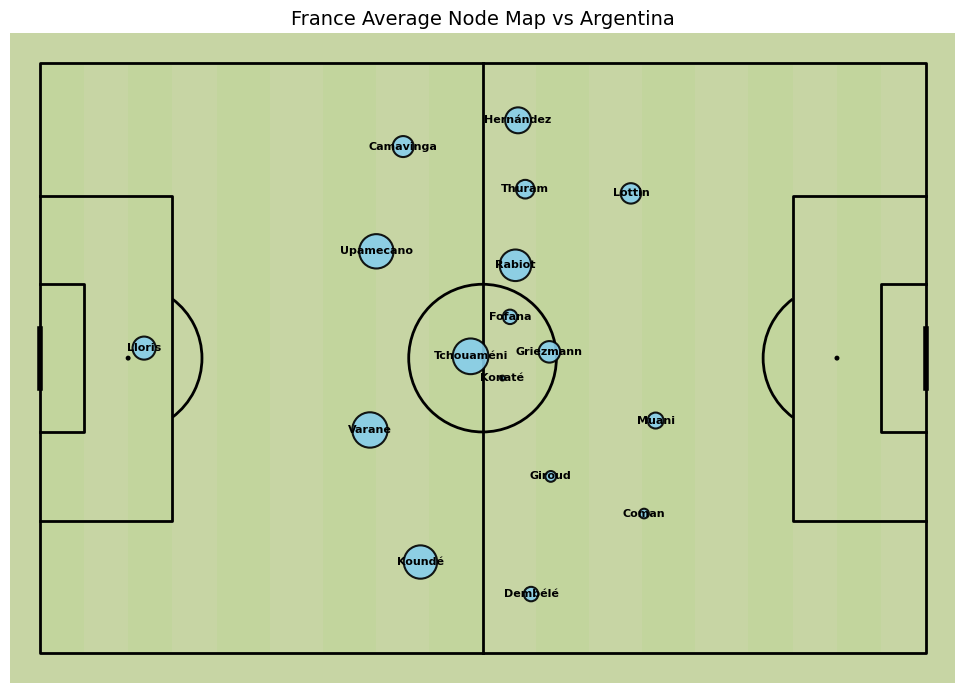

In [35]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#c7d5a4',
    stripe=True,
    line_color='black'
)

fig, ax = pitch.draw(figsize=(10, 7))

# Plot each player's average passing location
pitch.scatter(
    fra_nodes['avg_x'],
    fra_nodes['avg_y'],
    # Node size reflects pass volume
    s=fra_nodes['pass_count'] * 12,
    color='skyblue',
    edgecolors='black',
    linewidth=1.5,
    alpha=0.9,
    ax=ax
)

# Label nodes with player surnames 
for _, row in fra_nodes.iterrows():
    ax.text(
        row['avg_x'],
        row['avg_y'],
        row['player_name'].split()[-1],
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color='black'
    )

plt.title("France Average Node Map vs Argentina", fontsize=14)
plt.show()

## 11. France Average Node Map

###  Key Observations
- Camavinga shifts towards Messi’s side, providing defensive support on the left.
- Theo Hernández maintains an advanced position on the flank.
- Tchouaméni holds a central role, anchoring the midfield.
- Overall structure appears less compact compared to Argentina.

### Tactical Interpretation
Camavinga’s positioning towards Messi’s side reflects a defensive adjustment to contain Argentina’s main playmaker, 
allowing Theo Hernández to push forward and contribute offensively.

Tchouaméni acts as the central stabilizer, attempting to maintain balance in midfield, 
but the overall structure lacks compactness and coordinated spacing.

###  Match Impact
While France tries to balance defensive coverage and attacking width, 
the lack of compactness limits their ability to control central areas and maintain consistent structure.

In [36]:
# Argentina completed passes with known recipients
arg_passes = df[
    (df['team_name'] == 'Argentina') &
    (df['type_name'] == 'Pass') &
    (df['sub_type_name'] != 'Throw-in') &
    (df['outcome_name'].isna()) &
    (df['pass_recipient_name'].notna()) &
    (df['player_name'].notna())
].copy()

In [37]:
# Compute node positions and node sizes
arg_nodes = (
    arg_passes.groupby('player_name')
    .agg(
        avg_x=('x', 'mean'),
        avg_y=('y', 'mean'),
        pass_count=('id', 'count')
    )
    .reset_index()
)

In [38]:
arg_links = (
    arg_passes.groupby(['player_name', 'pass_recipient_name'])
    .size()
    .reset_index(name='pass_between')
)

# Keeping only the stronger links
arg_links = arg_links[arg_links['pass_between'] >= 3].copy()

In [39]:
# Attach starting node coordinates 
arg_links = arg_links.merge(
    arg_nodes[['player_name', 'avg_x', 'avg_y']],
    on='player_name',
    how='left'
).rename(columns={'avg_x': 'x', 'avg_y': 'y'})

# Attach ending node coordinates 
arg_links = arg_links.merge(
    arg_nodes[['player_name', 'avg_x', 'avg_y']],
    left_on='pass_recipient_name',
    right_on='player_name',
    how='left'
).rename(columns={'avg_x': 'end_x', 'avg_y': 'end_y'})

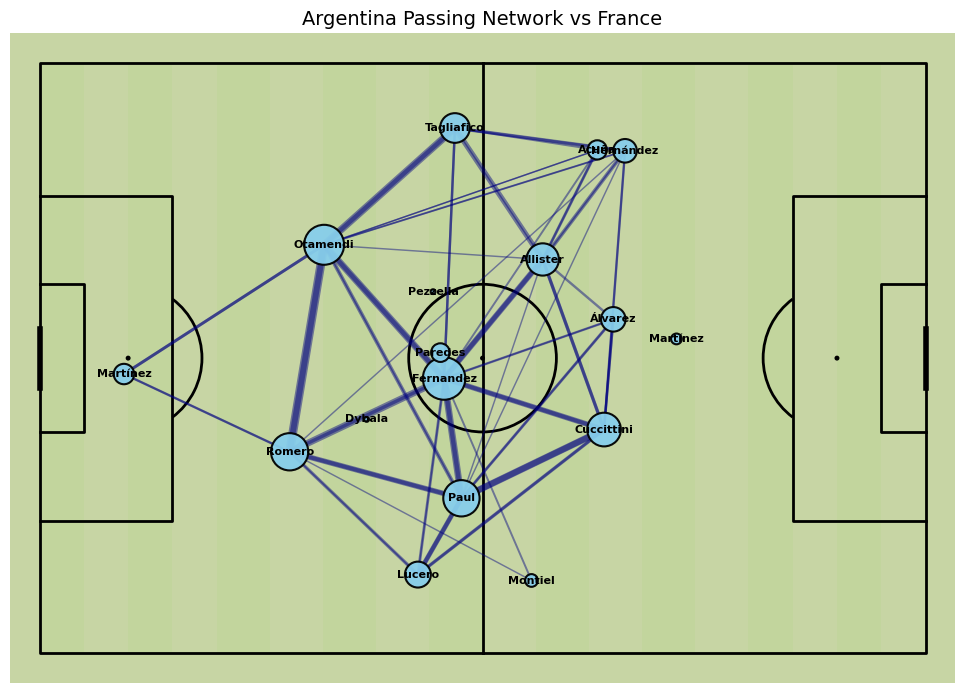

In [40]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#c7d5a4',
    stripe=True,
    line_color='black'
)

fig, ax = pitch.draw(figsize=(10, 7))

# Draw passing connections
for _, row in arg_links.iterrows():
    pitch.lines(
        row['x'], row['y'],
        row['end_x'], row['end_y'],
        #Line width reflects frequency of passes
        lw=row['pass_between'] * 0.35,
        color='navy',
        alpha=0.45,
        ax=ax,
        zorder=1
    )

# Plot player nodes
pitch.scatter(
    arg_nodes['avg_x'],
    arg_nodes['avg_y'],
    # Size reflects total pass involvement
    s=arg_nodes['pass_count'] * 12,
    color='skyblue',
    edgecolors='black',
    linewidth=1.5,
    alpha=0.95,
    ax=ax,
    zorder=2
)

# Label with player surnames
for _, row in arg_nodes.iterrows():
    ax.text(
        row['avg_x'],
        row['avg_y'],
        row['player_name'].split()[-1],
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color='black',
        zorder=3
    )

plt.title("Argentina Passing Network vs France", fontsize=14)
plt.show()

## 12. Argentina Passing Network

###  Key Observations
- Strong passing connections form multiple triangular and diamond structures.
- Enzo Fernández sits at the center of most passing combinations.
- Key links include Otamendi–Tagliafico–Mac Allister–Fernández and Fernández–Romero–De Paul–Messi.
- High connectivity between defense, midfield, and attack.

###  Tactical Interpretation
Argentina’s passing network reveals a highly structured positional play system built on geometric patterns such as triangles and diamonds. 
These shapes ensure constant passing options and facilitate smooth ball progression under pressure.

Enzo Fernández acts as the central hub, connecting multiple units across the pitch, 
while surrounding players maintain optimal spacing to preserve these structures.

###  Match Impact
This interconnected structure allows Argentina to circulate the ball efficiently and break lines consistently, 
making it extremely difficult for France to disrupt their build-up.

### Insight
Argentina doesn’t just pass — they construct geometry to control the game.

In [41]:
# Argentina completed passes with known recipients
fra_passes = df[
    (df['team_name'] == 'France') &
    (df['type_name'] == 'Pass') &
    (df['sub_type_name'] != 'Throw-in') &
    (df['outcome_name'].isna()) &
    (df['pass_recipient_name'].notna()) &
    (df['player_name'].notna())
].copy()

In [42]:
# Compute node positions and node sizes
fra_nodes = (
    fra_passes.groupby('player_name')
    .agg(
        avg_x=('x', 'mean'),
        avg_y=('y', 'mean'),
        pass_count=('id', 'count')
    )
    .reset_index()
)

In [43]:
fra_links = (
    fra_passes.groupby(['player_name', 'pass_recipient_name'])
    .size()
    .reset_index(name='pass_between')
)

# Keeping only the stronger links
fra_links = fra_links[fra_links['pass_between'] >= 3].copy()

In [44]:
# Attach starting node coordinates
fra_links = fra_links.merge(
    fra_nodes[['player_name', 'avg_x', 'avg_y']],
    on='player_name',
    how='left'
).rename(columns={'avg_x': 'x', 'avg_y': 'y'})

# Attach ending node coordinates 
fra_links = fra_links.merge(
    fra_nodes[['player_name', 'avg_x', 'avg_y']],
    left_on='pass_recipient_name',
    right_on='player_name',
    how='left'
).rename(columns={'avg_x': 'end_x', 'avg_y': 'end_y'})

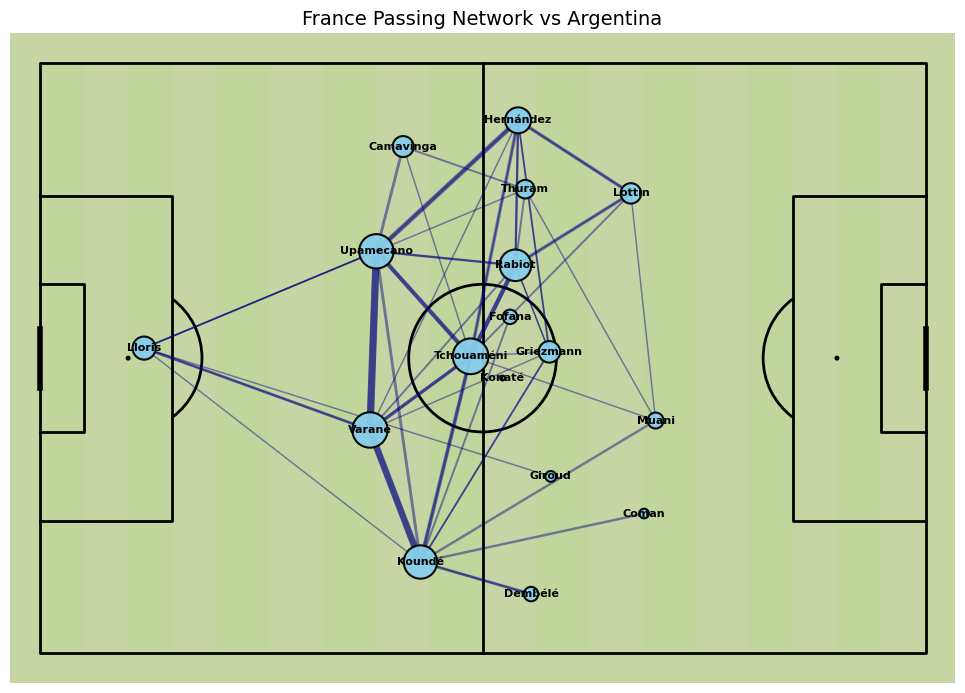

In [45]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#c7d5a4',
    stripe=True,
    line_color='black'
)

fig, ax = pitch.draw(figsize=(10, 7))

# Draw passing connections
for _, row in fra_links.iterrows():
    pitch.lines(
        row['x'], row['y'],
        row['end_x'], row['end_y'],
        #Line width reflects frequency of passes
        lw=row['pass_between'] * 0.35,
        color='navy',
        alpha=0.45,
        ax=ax,
        zorder=1
    )

# Plot player nodes 
pitch.scatter(
    fra_nodes['avg_x'],
    fra_nodes['avg_y'],
    # Size reflects total pass involvement
    s=fra_nodes['pass_count'] * 12,
    color='skyblue',
    edgecolors='black',
    linewidth=1.5,
    alpha=0.95,
    ax=ax,
    zorder=2
)

# Label with player surnames
for _, row in fra_nodes.iterrows():
    ax.text(
        row['avg_x'],
        row['avg_y'],
        row['player_name'].split()[-1],
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color='black',
        zorder=3
    )

plt.title("France Passing Network vs Argentina", fontsize=14)
plt.show()

## 13. France Passing Network

###  Key Observations
- The passing network appears fragmented and less structured compared to Argentina.
- Very limited connection between Koundé and Dembélé on the right flank.
- High volume of passes between center-backs (Varane–Upamecano).
- Weak connections between midfield and attacking lines.

###  Tactical Interpretation
France struggles to establish a coherent passing structure, with most circulation happening between defenders rather than progressing forward. 
The lack of connection on the right flank (Koundé–Dembélé) significantly reduces their ability to create width and attacking options.

Instead of forming stable geometric patterns, the team relies on isolated links and disconnected movements, 
limiting overall creativity and fluidity.

###  Match Impact
This defensive-heavy circulation and lack of wide connectivity make France predictable and easier to contain, 
especially in structured phases of play.

###  Insight
France passes the ball, but fails to connect the game.

In [46]:
# Extract all shot events
shots = df[df['type_name'] == 'Shot'].copy()

shots = shots[
    shots['shot_statsbomb_xg'].notna()
].copy()

In [47]:
arg_shots = shots[shots['team_name'] == 'Argentina']
fra_shots = shots[shots['team_name'] == 'France']

In [48]:
# Sort shots chronologically and compute cumulative xG over time
arg_shots = arg_shots.sort_values('minute')
fra_shots = fra_shots.sort_values('minute')

arg_shots['cum_xg'] = arg_shots['shot_statsbomb_xg'].cumsum()
fra_shots['cum_xg'] = fra_shots['shot_statsbomb_xg'].cumsum()

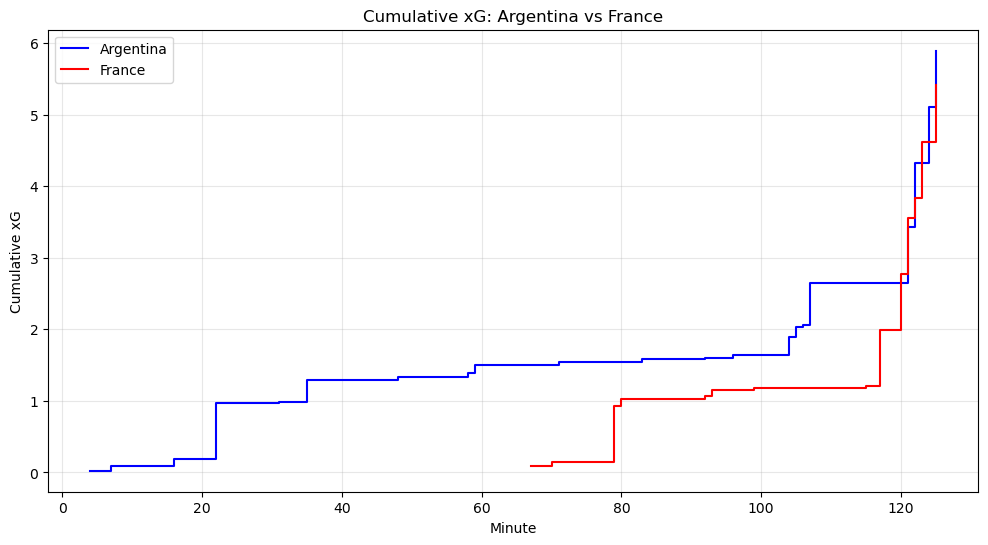

In [49]:
# Plot cumulative xG as a step function
plt.figure(figsize=(12,6))

plt.step(
    arg_shots['minute'],
    arg_shots['cum_xg'],
    where='post',
    color='blue',
    label='Argentina'
)

plt.step(
    fra_shots['minute'],
    fra_shots['cum_xg'],
    where='post',
    color='red',
    label='France'
)

plt.xlabel("Minute")
plt.ylabel("Cumulative xG")
plt.title("Cumulative xG: Argentina vs France")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 14. Cumulative xG

###  Key Observations
- Argentina consistently maintains a higher cumulative xG throughout most of the match.
- France shows very limited xG generation until the later stages.
- A sharp increase in France’s xG occurs late in the game.

###  Tactical Interpretation
Argentina demonstrates sustained attacking production and control, consistently creating higher-quality chances. 
In contrast, France struggles to generate opportunities within structured play for most of the match.

However, this pattern is disrupted by Mbappé’s individual brilliance, which rapidly elevates France’s xG in a short period.

###  Match Impact
Despite Argentina’s overall dominance in chance creation, 
Mbappé’s decisive moments shift the momentum and bring France back into the game.

### Insight
Football is not only about sustained superiority, it can also be defined by moments of brilliance.

## Conclusion

This analysis highlights the contrast between structured dominance and individual brilliance in the 2022 World Cup Final.

Argentina controlled the game through a well-organized system, positional discipline, and consistent chance creation. 
In contrast, France relied on moments of individual excellence, particularly through Mbappé, to remain competitive.

Ultimately, this match demonstrates that while structure provides control, 
decisive moments can redefine outcomes at the highest level of football.

**Author:** Alper Karayaz
